![UTFSM](https://github.com/tclaudioe/Scientific-Computing-V3/blob/main/images/Departamento%20de%20Inform%C3%A1tica%20cromatica%20negra%404x-8.png?raw=true)
# INF-285 - Computación Científica
## My first Least Squares problem
## Version: 1.00

<a id="toc"></a>

# Table of Contents
* [Introduction](#Introduction)
* [Minimal Example](#Minimal-Example)
* [First Example](#First-Example)
* [Second Example](#Second-Example)
* [Acknowledgements](#Acknowledgements)

In [2]:
import importlib.util
import sys
import subprocess
import os

##########################
# CoLab requirements
# https://stackoverflow.com/questions/44210656/how-to-check-if-a-module-is-installed-in-python-and-if-not-install-it-within-t
##########################
    
# install_colab_requirements 
libraries = ['numpy', 'scipy', 'matplotlib', 'colorama', 
            'bitstring', 'sympy', 'ipywidgets','pandas']

for library in libraries:
    # Check if the library is already installed
    if importlib.util.find_spec(library) is not None:
        print(f"{library} is already installed.")
    else:
        print(f"{library} is not installed. Installing...")
        # Install the library using pip
        subprocess.check_call([sys.executable, "-m", "pip", "install", library])
        print(f"{library} has been installed.")
# https://stackoverflow.com/questions/53581278/test-if-notebook-is-running-on-google-colab
if os.getenv("COLAB_RELEASE_TAG"):
    print('Installing LaTeX support in CoLab')
    # Adding LaTeX dependencies to CoLab: https://stackoverflow.com/questions/55746749/latex-equations-do-not-render-in-google-colaboratory-when-using-matplotlib
    !sudo apt install cm-super dvipng texlive-latex-extra texlive-latex-recommended
else:
   print('Running on local environment')

numpy is already installed.
scipy is already installed.
matplotlib is already installed.
colorama is already installed.
bitstring is already installed.
sympy is already installed.
ipywidgets is already installed.
pandas is already installed.
Running on local environment


In [3]:
import numpy as np # type: ignore
import matplotlib.pyplot as plt # type: ignore
import scipy.linalg as spla # type: ignore
%matplotlib inline
# https://scikit-learn.org/stable/modules/classes.html#module-sklearn.datasets
from sklearn import datasets # type: ignore
import ipywidgets as widgets # type: ignore
from matplotlib.patches import Polygon # type: ignore
import matplotlib as mpl # type: ignore
mpl.rcParams['font.size'] = 12
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['text.usetex'] = True
M=8
from ipywidgets import interact # type: ignore
# https://pypi.org/project/colorama/
# %conda install -c anaconda colorama
# or
# !pip install colorama
from colorama import Fore, Back, Style # type: ignore
# https://pypi.org/project/colorama/
# Fore: BLACK, RED, GREEN, YELLOW, BLUE, MAGENTA, CYAN, WHITE, RESET.
# Back: BLACK, RED, GREEN, YELLOW, BLUE, MAGENTA, CYAN, WHITE, RESET.
# Style: DIM, NORMAL, BRIGHT, RESET_ALL
textBold = lambda x: Style.BRIGHT+x+Style.RESET_ALL
textBoldH = lambda x: Style.BRIGHT+Back.YELLOW+x+Style.RESET_ALL

textQRClassic = lambda x: Style.BRIGHT+Fore.RED+x+Style.RESET_ALL
textQRModified = lambda x: Style.BRIGHT+Fore.BLUE+x+Style.RESET_ALL
textAnswer = lambda x: Style.BRIGHT+Back.YELLOW+Fore.WHITE+x+Style.RESET_ALL

# Introduction
[Back to TOC](#toc)

This jupyter notebook presents a short but detailed introduction to least square problems.
It starts with a 1D problem and then it shows 1 2D extension.

# Minimal Example
[Back to TOC](#toc)

This will be the *smallest* possible least-squares problem.
Anything smaller may not be possible!

Let's say you have two measurements of a quantity, say $y_0=1.3$ and $y_1=1.15$.
Now, you are asked to find a values that minimizes the least-square error respect to both quantities at the same time.
From the algebraic point of view, this will have two mathematical representations:

- **First representation**: from a minimization point of view
$$
\begin{align*}
    E(a) &= (y_0-a)^2+(y_1-a)^2,
\end{align*}
$$
where $E(a)$ represents the quadratic error as a function of the variable $a$.
- **Second representation**: from the Linear Algebra point of view
$$
\begin{align*}
    a+r_0 &= y_0,\\
    a+r_1 &= y_1.\\ 
\end{align*}
$$
where we want to find $a$ such that it minimizes the norm-$2$ of the residual $\mathbf{r}=\begin{bmatrix}r_0, & r_1\end{bmatrix}^{\top}$.
Specifically, we can rewrite the previous expresion as follows,
$$
\begin{align*}
    r_0 &= y_0-a,\\
    r_1 &= y_1-a.\\
\end{align*}
\quad
\rightarrow
\quad
\begin{align*}
    \mathbf{r} &= 
    \underbrace{\begin{bmatrix}
        y_0\\
        y_1
    \end{bmatrix}}_{\displaystyle\mathbf{b}}
    -
    \begin{bmatrix}
        a\\
        a
    \end{bmatrix}
    =
    \mathbf{b}
    -
    \underbrace{\begin{bmatrix}
        1\\
        1
    \end{bmatrix}}_{\displaystyle\mathbf{1}}\,a.
\end{align*}
$$
Then, the norm-$2$ of the residual is the following,
$$
\begin{align*}
    \|\mathbf{r}\|_2^2 &= \|\mathbf{b}-\mathbf{1}\,a\|_2^2=
        \left\|
        \begin{bmatrix}
            y_0-a\\
            y_2-a
        \end{bmatrix}
        \right\|_2^2=(y_0-a)^2+(y_1-a)^2.
\end{align*}
$$
Therefore, we can conclude that both representation are exactly the same!

The interesting point is that each representation uses a different but equivalent procedure to find the minimum of $E(a)=\|\mathbf{r}\|_2^2$.


## Finding the minimum for the "First representation - from a minimization point of view"

The minimization of the function $E(a) = (y_0-a)^2+(y_1-a)^2$ is straing forward, i.e. we need to compute it derivative, thus,
$$
\begin{align*}
    E'(a) &= \dfrac{\mathrm{d}}{\mathrm{d}a}\left((y_0-a)^2+(y_1-a)^2\right),\\
        &= 2\,(y_0-a)\,(-1)+2\,(y_1-a)\,(-1).
\end{align*}
$$
Now, finding the critical point we get,
$$
\begin{align*}
    E'(\overline{a}) &= 0,\\
    2\,(y_0-\overline{a})\,(-1)+2\,(y_1-\overline{a})\,(-1) &= 0,\\
    (y_0-\overline{a})+(y_1-\overline{a}) &= 0,\\
    2\,\overline{a} &= y_0+y_1,\\
    \overline{a} &= \dfrac{y_0+y_1}{2}.
\end{align*}
$$
Notice that in this case we used $\overline{a}$ to denote the value for the variable $a$ that minimizes $E(a)$.
Now, to check it is a minimum, we could apply the second derivative test, thus,
$$
\begin{align*}
    E''(a) &= \dfrac{\mathrm{d}^2}{\mathrm{d}a^2}\left((y_0-a)^2+(y_1-a)^2\right),\\
        &= 2+2,\\
        &= 4.
\end{align*}
$$
Therefore, it is a minimum.

## Finding the minimum for the "Second representation - from the Linear Algebra point of view"

For this second representation, it is a bit more _intense_ the formulation, but it then generalizes much better!
Now, recall the **residual** representation,
$$
\begin{align*}
    \mathbf{r} &= 
    \begin{bmatrix}
        y_0\\
        y_1
    \end{bmatrix}
    -
    a\,
    \begin{bmatrix}
        1\\
        1
    \end{bmatrix}.
\end{align*}
\quad
\rightarrow
\quad
\begin{align*}
    \mathbf{r} &= 
    {\color{blue}\underbrace{\begin{bmatrix}
        1.3\\
        1.15
    \end{bmatrix}}_{\displaystyle\mathbf{b}}}
    -
    {\color{red} a\,
    \underbrace{\begin{bmatrix}
        1\\
        1
    \end{bmatrix}}_{\displaystyle\mathbf{1}}}.
\end{align*}
$$
Next, it is natural to represent graphically the vectors ${\color{blue} \mathbf{b}}$ and ${\color{red} a\,\mathbf{1}}$.
Notice that ${\color{red} a\,\mathbf{1}}$ is not just **a** vector, it is actually a vector sub-space where a base of it is the vector ${\color{red} \mathbf{1}}$.
So, we actually need to plot the vector sub-space as a line in this case, where the sub-space is obtained from selecting different values of $a$ that scales the vector ${\color{red} \mathbf{1}}$.

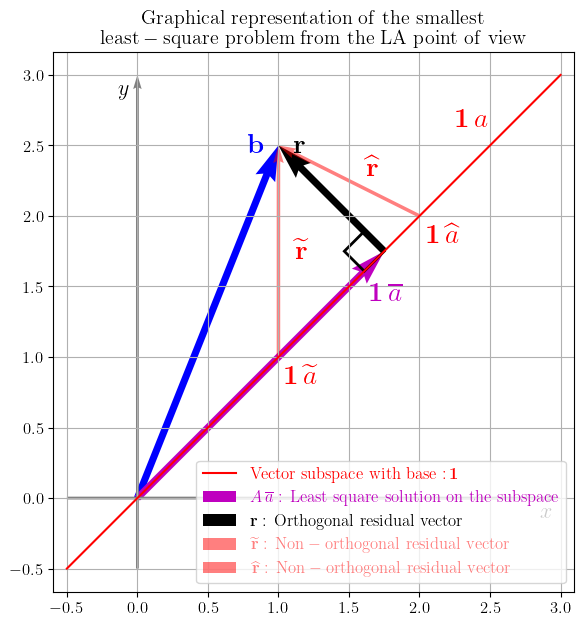

In [94]:
plt.figure(figsize=(6,6))

A = np.ones((2,1))
b = np.array([[1],[2.5]])
# Using the Normal Equations!
a_bar = np.linalg.solve(A.T@A,A.T@b)
A_a_bar = A@a_bar
r = b - A_a_bar

eps = 0.1
# Right-Hand-Side vector, in this case it is "y".
plt.quiver(0, 0, b[0], b[1], color='b', scale=1, units='xy', angles='xy', width=0.05)
plt.text(b[0]-eps, b[1], r'$\mathbf{b}$', fontsize=20, ha='right', va='center', color='b')

# Plotting the sub-space "A*a"
min_x, max_x = -0.5, 3
x = np.linspace(min_x, max_x,100)
plt.plot(x, x, 'r-', label=r'$\mathrm{Vector\ subspace\ with\ base:}\,\mathbf{1}$')
plt.text(2.5, 2.5+eps, r'$\mathbf{1}\,a$', fontsize=20, ha='right', va='bottom', color='r')

# The least-square solution on the sub-space
plt.quiver(0, 0, A_a_bar[0], A_a_bar[1], color='m', scale=1, units='xy', angles='xy', width=0.05, label=r'$A\,\overline{a}:\,\mathrm{Least\ square\ solution\ on\ the\ subspace}$')
plt.text(A_a_bar[0]-eps, A_a_bar[1]-3*eps, r'$\mathbf{1}\,\overline{a}$', fontsize=20, ha='left', va='center', color='m')

# The minimal residual vector
plt.quiver(0+A_a_bar[0], 0+A_a_bar[1], r[0], r[1], color='k', scale=1, units='xy', angles='xy', width=0.05, label=r'$\mathbf{r}:\,\mathrm{Orthogonal\ residual\ vector}$')
plt.text(A_a_bar[0]+r[0]+eps, A_a_bar[1]+r[1], r'$\mathbf{r}$', fontsize=20, ha='left', va='center', color='k')

# Another residual vectors
# \widetilde{\mathbf{r}}
r_tilde = b-np.array([[1],[1]])
plt.quiver(1, 1, r_tilde[0], r_tilde[1], color='r', scale=1, units='xy', angles='xy', width=0.025, alpha=0.5, label=r'$\widetilde{\mathbf{r}}:\,\mathrm{Non-orthogonal\ residual\ vector}$')
plt.text(1+eps, 1.75, r'$\widetilde{\mathbf{r}}$', fontsize=20, ha='left', va='center', color='r')
plt.text(1+eps/2, 1-eps/2, r'$\mathbf{1}\,\widetilde{a}$', fontsize=20, ha='left', va='top', color='r')
# \widehat{\mathbf{r}}
r_hat = b-np.array([[2],[2]])
plt.quiver(2, 2, r_hat[0], r_hat[1], color='r', scale=1, units='xy', angles='xy', width=0.025, alpha=0.5, label=r'$\widehat{\mathbf{r}}:\,\mathrm{Non-orthogonal\ residual\ vector}$')
plt.text(1.5+eps, 2.25, r'$\widehat{\mathbf{r}}$', fontsize=20, ha='left', va='bottom', color='r')
plt.text(2+eps/2, 2-eps/2, r'$\mathbf{1}\,\widehat{a}$', fontsize=20, ha='left', va='top', color='r')
# Additional text

# x-axis
plt.quiver(min_x, 0, max_x-min_x, 0, color='gray', scale=1, units='xy', angles='xy', width=0.02)
plt.text(max_x-eps, -0.1, r'$x$', fontsize=16, ha='center', va='center')
# y-axis
plt.quiver(0, min_x, 0, max_x-min_x, color='gray', scale=1, units='xy', angles='xy', width=0.02)
plt.text(-0.1, max_x-eps, r'$y$', fontsize=16, ha='center', va='center')

plt.grid()
plt.axis('equal')
plt.tight_layout()

# Including a square to indicate orthogonality
theta = np.deg2rad(45) # convert to radians
side = 0.2
square = np.array([
    [0, 0],             # bottom-right (pivot)
    [-side, 0],         # bottom-left
    [-side, side],      # top-left
    [0, side]           # top-right
])
# Rotation matrix
R = np.array([  [np.cos(theta), -np.sin(theta)],
                [np.sin(theta),  np.cos(theta)]])
rotated_square = square @ R.T + A_a_bar.T  # Shifting to the A\,a_bar point
ax = plt.gca()
# Plotting the square
ax.add_patch(Polygon(rotated_square, closed=True, facecolor='none', edgecolor='k', linewidth=2))

plt.title(r'$\mathrm{Graphical\ representation\ of\ the\ smallest}$'+'\n'+r'$\mathrm{least-square\ problem\ from\ the\ LA\ point\ of\ view}$')

plt.legend(loc='best', fontsize=12, labelcolor='linecolor')
plt.show()


So, from the previous figure we clearly obser that the minimum residual is achieved when the residual vector $\mathbf{r}$ is orthogonal to the vector subspace generated by scaling the base vector ${\color{red} \mathbf{1}}$.
The other two vectors, ${\color{red} \widehat{\mathbf{r}}}$ and ${\color{red} \widetilde{\mathbf{r}}}$, are included as examples of non-optimal solution in the least-square sense, which means to have the lowest norm-$2$ of the residual vectors.
Nota that any residual vector that is different that $\mathbf{r}=\mathbf{b}-\mathbf{1}\,\overline{a}$ will have a larger norm-$2$.

This previous Figure is what we claim the _smallest_ least-square problem possible, however it has the feature and the beauty that generalize the key points very well!

# First Example
[Back to TOC](#toc)

Now, what we call the _First Example_ is just the same previous example but extended to several measurements points.
This means that we will have $m$ points.
The idea is the same, find the _coefficient_, in this case $c$, that minimizes the least-square problem.

The set-up of this experiment is the following:
1. We generate $m=100$ points that follows a normal distribution with mean $\mu=4$ and standard deviation $\sigma=1$. This data-points will be plotted in ${\color{blue} \mathrm{blue}}$.
2. The exact value of the mean $\mu$ will be shown in ${\color{black} \mathrm{black}}$.
3. The least-square solution will be displayed in ${\color{magenta} \mathrm{magenta}}$. **Notice that this does not necesarrily matches the theoretical exact solution in black! However, it will get better if you increase the sample size!**.
4. The _interact_ value for $c$ will be displayed in ${\color{red} \mathrm{red}}$, and the purpose of this to show what ones get if we don't select the minimum value.

In [ ]:
def show_1d_error(c_input=2.5, m=100):
    c_exact = 4
    rng = np.random.default_rng(0)
    c_data = rng.normal(loc=c_exact, scale=1., size=m)

    ones_data = np.ones_like(c_data)
    # Using the Normal Equations!
    c_bar = np.dot(ones_data,c_data)/np.dot(ones_data,ones_data)

    plt.figure(figsize=(8,8))

    plt.subplot(221)
    plt.plot(np.arange(m),c_data, '.b', markersize=10, alpha=0.5)
    plt.title(r'$\mathrm{Data\ points\ }c_i\sim \mathcal{N}(4,1)$')
    plt.xlabel(r'$\mathrm{Index\, of\, data\, point:}\, i$')
    plt.grid(True)
    plt.plot(np.arange(m),ones_data*c_bar, '-m', linewidth=2, label=r'$\mathrm{LS\, approx\ }c^*=\frac{\mathbf{1}^T\mathbf{c}}{\mathbf{1}^T\mathbf{1}}$')
    plt.plot(np.arange(m),ones_data*c_exact,'-k', linewidth=2, label=r'$\mathrm{Exact\ value\ }c_{\mathrm{exact}}=4$')
    plt.plot(np.arange(m),ones_data*c_input,'-r', linewidth=2, label=r'$\mathrm{Input\ evaluation\ }c$')

    plt.subplot(222)
    plt.hist(c_data, bins=15, density=True, alpha=0.5, color='b')
    plt.title(r'$\mathrm{Histogram\ of\ data\ points}$')
    plt.xlabel(r'$c_i$')
    plt.grid(True)
    plt.axvline(c_bar, color='m', linestyle='-', linewidth=2, label=r'$\mathrm{LS\, approx\ }c^*=\frac{\mathbf{1}^T\mathbf{c}}{\mathbf{1}^T\mathbf{1}}$')
    plt.axvline(c_exact, color='k', linestyle='-', linewidth=2, label=r'$\mathrm{Exact\ value\ }c_{\mathrm{exact}}=4$')
    plt.axvline(c_input, color='r', linestyle='-', linewidth=2, label=r'$\mathrm{Input\ evaluation\ }c$')

    plt.subplot(223)
    
    c = np.linspace(0,2,m)
    plt.plot(np.ones_like(c_data),c_data, '.b', markersize=10, alpha=0.5)
    plt.plot(c,ones_data*c_bar, '-m', linewidth=2, label=r'$\mathrm{LS\, approx\ }c^*=\frac{\mathbf{1}^T\mathbf{c}}{\mathbf{1}^T\mathbf{1}}$')
    plt.plot(c,ones_data*c_exact,'-k', linewidth=2, label=r'$\mathrm{Exact\ value\ }c_{\mathrm{exact}}=4$')
    plt.plot(c,ones_data*c_input,'-r', linewidth=2, label=r'$\mathrm{Input\ evaluation\ }c$')
    ax = plt.gca()
    ax.set_xticks([1],[r'$\mathrm{Data}$'])
    plt.ylabel(r'$y_i$')
    plt.title(r'$\mathrm{Data\ points\ }y_i\sim \mathcal{N}(4,1)$')
    plt.grid(True)

    plt.subplot(224)
    error_c = np.vectorize(lambda c: np.power(np.linalg.norm(c_data-c*ones_data),2.))
    c = np.linspace(2,6,m)
    plt.plot(c,error_c(c), '-b', linewidth=2, label=r'$\mathrm{Error\ }\|\mathbf{c}-c\,\mathbf{1}\|_2^2$')
    plt.plot(c_bar,error_c(c_bar), 'om', markersize=10, alpha=0.5, label=r'$\mathrm{LS\, approx\ }c^*=\frac{\mathbf{1}^T\mathbf{c}}{\mathbf{1}^T\mathbf{1}}$')
    plt.plot(c_exact,error_c(c_exact),'ok', markersize=10, alpha=0.5, label=r'$\mathrm{Exact\ value\ }c_{\mathrm{exact}}=4$')
    plt.plot(c_input,error_c(c_input),'*r', markersize=10, alpha=0.5, label=r'$\mathrm{Input\ evaluation\ }c$')
    plt.xlabel(r'$\mathrm{Value\ of\ }c\mathrm{\ selected}$')
    plt.title(r'$\mathrm{Error\ as\ a\ function\ of\ }c$')
    plt.xlim([2,6])
    plt.legend(loc='best',bbox_to_anchor=(1, 0.5))
    plt.grid(True)
    
    plt.subplots_adjust(wspace=0.25, hspace=0.35)

    plt.show()
interact(show_1d_error, \
    c_input=widgets.FloatSlider(value=2.5, min=2., max=6., step=0.1, description=r'c'), \
        m=widgets.IntSlider(value=100, min=100, max=3000, step=10, description=r'm'))

interactive(children=(FloatSlider(value=2.5, description='c', max=6.0, min=2.0), IntSlider(value=100, descript…

<function __main__.show_1d_error(c_input=2.5, m=100)>

# Second Example
[Back to TOC](#toc)

This _Second Example_ is a more traditional one.
We generate $m$ equalspaced points in the domain $[0,1]$ and we denote them as $x_i$, we then generate the $y_i$ as follows,
$$
\begin{align*}
    y_i &= a_0^{\mathrm{[exact]}}+a_1^{\mathrm{[exact]}}\,x_i+e_i,
\end{align*}
$$
where $a_0^{\mathrm{[exact]}}=1$, $a_1^{\mathrm{[exact]}}=4$, and $e_i\sim\mathcal{N}(0,\sigma)$, i.e. it follows a normal distribution with mean $0$ and standar deviation equal to $\sigma=10^{-5}$.
Now, we aim to recover the values of $(a_0^{\mathrm{[exact]}},a_1^{\mathrm{[exact]}})$ from that ordered pair $(x_i,y_i)$ by means of a least-square approximation.

In this case, similarly to the previous example, the _interact_ allows us to _test_ different approximations for the ordered pair $(a_0,a_1)$.
For completeness, we repeat the notation:
1. In ${\color{blue} \mathrm{blue}}$ the data-points.
2. In ${\color{black} \mathrm{black}}$ the _exact_ solution.
3. In ${\color{magenta} \mathrm{magenta}}$ the least-square approximation.
4. In ${\color{red} \mathrm{red}}$ the _test_ approximation we are selecting in the _interact_.


In [ ]:
def show_least_square_approximation(a0_test=4, a1_test=1):
    # Number of points to be used
    m = 100
    # Relationship considered
    fv = np.vectorize(lambda x, a0, a1: a0+a1*x)
    # "Exact" coefficients considered
    a0_exact, a1_exact = 1, 4

    # Fixing the 'seed' of the random number generator to obtain reproducible outcomes.
    rng = np.random.Generator(np.random.PCG64(seed=0))

    # Error:
    # Standard deviation for the error
    sigma = 5e-1
    # Error to be added
    e = rng.normal(0, sigma, m)

    # Generating data points
    x = np.linspace(0,1,m)
    y = fv(x,a0_exact,a1_exact)+e
    # Challenging question: What if all the xi are the same?
    # This means that considering the following definition for x, for instance:
    # x = np.linspace(0,1,m)*0+0.5

    A = np.vstack((np.ones(m), x)).T
    # Using the Normal Equations!
    x_sol = np.linalg.solve(A.T @ A, A.T @ y)
    a0_ls, a1_ls = x_sol

    # Plotting the data
    plt.figure(figsize=(10,5))
    plt.subplot(121)
    plt.plot(x,y,'b.',markersize=10, label='Data points')
    plt.plot(x,fv(x,a0_exact,a1_exact),'k-',linewidth=4,alpha=0.8, label='Original function')
    plt.plot(x,fv(x,a0_ls,a1_ls),'m--',linewidth=4,alpha=0.8, label='Least squares solution')
    plt.plot(x,fv(x,a0_test,a1_test),'r-',linewidth=4,alpha=0.8, label='Test approximation')
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(True)
    plt.xlabel(r'$x$')
    plt.ylabel(r'$y$')
    plt.title(r'$a_0+a_1\,x$')

    residual = np.vectorize(lambda a0,a1: np.power(np.linalg.norm(y-fv(x,a0,a1)),2))
    ab_domain = np.linspace(0,5,100)
    A0,A1 = np.meshgrid(ab_domain, ab_domain)
    R = residual(A0,A1)
    plt.subplot(122)
    plt.title(r'$\mathrm{Residual:}$ $\|\mathbf{b} - A\,\mathbf{x}\|_2^2$'+f'\n'+r'$=\sum_{i=1}^n (y_i-a_0-a_1\,x_i)^2$')
    plt.contourf(A0,A1,R,levels=50,cmap='YlGn')
    plt.colorbar()
    plt.plot(a0_exact,a1_exact,'k*',markersize=15, label='Exact coefficients',alpha=0.6)
    plt.plot(a0_ls,a1_ls,'m*',markersize=15, label='Least squares solution',alpha=0.6)
    plt.plot(a0_test,a1_test,'*r',markersize=15, label='Test coefficients',alpha=0.6)
    plt.xlabel(r'$a_0$')
    plt.ylabel(r'$a_1$')

    plt.show()

interact(show_least_square_approximation, a0_test=(0,5,0.1), a1_test=(0,5,0.1))

interactive(children=(FloatSlider(value=4.0, description='a0_test', max=5.0), FloatSlider(value=1.0, descripti…

<function __main__.show_least_square_approximation(a0_test=4, a1_test=1)>

For this previous example we only show the plots for the approximation and the value for the residual for simplicity.
To show the residual vector will requiere to plot a 100-dimensional vector in a 2D screen, which will be challenging!
Anyhow, the purpose of the Figures is to make the connection between reducing the residual and its connection in how well it fits the data.

# Acknowledgements
[Back to TOC](#toc)
* _Material created by professor Claudio Torres_ (`claudio.torres@usm.cl`) DI UTFSM. October 2025.- v1.0.